In [35]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def _load_ablation_scores(model, attribution, dataset, ablation_type):
    src_dir = f"/mnt/dacslab/dpa/results/ablation__{model.lower().replace('/', '_').replace('-', '_')}__{dataset}"
    methods = []
    for fname in os.listdir(src_dir):
        if fname.startswith(f"{attribution}_{ablation_type}_"):
            methods.append(
                fname.removeprefix(f"{attribution}_{ablation_type}_").removesuffix('.json')
            )

    scores = {}
    for method in methods:
        scores[method] = {}
        with open(os.path.join(src_dir, f"{attribution}_{ablation_type}_{method}.json")) as f:
            data = json.load(f)
        for sample in data:
            for noise_lvl_str, value in sample['scores'].items():
                noise = float(noise_lvl_str.removeprefix('noise_'))
                if noise not in scores[method]:
                    scores[method][noise] = []
                scores[method][noise].append(value)

    return scores, sorted(methods)


def _get_plot_params(attribution, ablation_type):
    if attribution == 'component':
        if ablation_type == 'recover':
            base_points = {1e-6: 0, 1.0: 100}
            legend_loc = 'upper left'
        else:
            base_points = {1e-10: 100}
            legend_loc = 'upper right'
        xscale = 'log'
    else:
        if ablation_type == 'recover':
            base_points = {1.0: 100}
            legend_loc = 'lower right'
        else:
            base_points = {0.0: 100}
            legend_loc = 'upper right'
        xscale = None
    return base_points, legend_loc, xscale


def _compute_avg_scores(scores, attribution, ablation_type):
    base_points, _, _ = _get_plot_params(attribution, ablation_type)
    avg_scores = {}
    for method in scores:
        avg_scores[method] = {}
        for noise_key, value in base_points.items():
            avg_scores[method][noise_key] = value
        for noise_level in scores[method]:
            values = scores[method][noise_level]
            avg_scores[method][noise_level] = 100 - np.mean(values).item()
    return avg_scores


def _get_method_order(attribution, methods):
    if attribution == 'input':
        method_order = [
            'random',
            'last_layer_attn',
            'mean_attn',
            'attn_rollout',
            'rollout',
            'gradient',
            'integrated_gradient',
            'input_x_gradient',
            'depass',
            'ifr',
            'dpa_025_025_05_05_05',
            'dpa',
            'ap'
        ]
        label_map = {
            'decompose': 'DePass',
            'input_x_gradient': 'Input X Gradient',
            'last_layer_attn': 'Last layer',
            'mean_attn': 'Mean',
            'attn_rollout': 'Rollout',
            'rollout': 'Rollout',
            'integrated_gradient': 'Integrated Gradients',
            'depass': 'DePass',
            'attn_act': 'Attn_only',
            'gradient': 'Gradient',
            'mlp_act': 'Mlp_act',
            'norm': 'Norm',
            'random': 'Random',
            'ifr': 'IFR',
            'dpa_025_025_05_05_05': 'DPA',
            'dpa': 'DPA',
        }
    else:
        method_order = methods
        label_map = {
            'decompose': 'DePass',
            'input_x_gradient': 'AtP',
            'atp': 'AtP',
            'attn_act': 'Attn-only',
            'gradient': 'Gradient',
            'mlp_act': 'MLP-only',
            'norm': 'Norm-only',
            'random': 'Random',
            'ifr': 'IFR',
            'dpa_025_025_05_05_05': 'DPA',
            'dpa': 'DPA',
        }
    return method_order, label_map


def plot_ablation_results(model, attribution, dataset, ablation_type):
    scores, methods = _load_ablation_scores(model, attribution, dataset, ablation_type)
    avg_scores = _compute_avg_scores(scores, attribution, ablation_type)

    plt.figure(figsize=(9, 6))

    method_order, label_map = _get_method_order(attribution, methods)

    # Keep only canonical Dpa among dpa_* variants and exclude AP from plots.
    method_order = [
        method
        for method in method_order
        if method != 'ap' and not (method.startswith('dpa_') and method != 'dpa_025_025_05_05_05')
    ]

    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    method_colors = {m: default_colors[i % len(default_colors)] for i, m in enumerate(method_order)}

    for method in method_order:
        if method not in avg_scores:
            continue
        noise_levels = sorted(avg_scores[method].keys())
        avg_values = [avg_scores[method][noise] for noise in noise_levels]
        label = label_map.get(method, method)

        plt.plot(
            noise_levels,
            avg_values,
            marker='o',
            label=label,
            linewidth=2,
            markersize=5,
            color=method_colors.get(method),
        )

    if ablation_type == 'recover':
        x_text = 'Recover Percent'
        title_action = 'Recover'
    else:
        x_text = 'Disrupt Percent'
        title_action = 'Disrupt'
    
    if dataset == 'imdb':
        dataset_title = 'IMDb'
    elif dataset == 'squad_v2.0':
        dataset_title = 'SQuAD v2.0'
    elif dataset == 'known_1000':
        dataset_title = 'Known 1000'
    elif dataset == 'ioi':
        dataset_title = 'IOI'

    title_text = f"Dataset: {dataset_title}\n{title_action} Top Percent Token"

    _, legend_loc, xscale = _get_plot_params(attribution, ablation_type)

    plt.xlabel(x_text, fontsize=16)
    plt.ylabel('Average reletive prob.', fontsize=16)
    plt.title(title_text, fontsize=24, pad=20)

    plt.legend(loc=legend_loc,fontsize=16)
    plt.xticks(fontsize=18)
    if xscale == 'log':
        plt.xscale('log', base=10)
    plt.yticks(fontsize=18)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.show()


def plot_input_results_three_datasets(model, attribution='input', datasets=None):
    model_key = model.lower()

    if datasets is None:
        if 'qwen/qwen2.5-32b-instruct' in model_key:
            datasets = ['known_1000']
        elif attribution == 'input' and (
            'qwen/qwen3-4b-instruct-2507' in model_key
            or 'mistralai/mistral-7b-instruct-v0.3' in model_key
        ):
            datasets = ['known_1000', 'squad_v2.0']
        elif attribution == 'component':
            datasets = ['known_1000', 'ioi']
        else:
            datasets = ['known_1000', 'squad_v2.0', 'imdb']

    ablation_types = ['disrupt', 'recover']
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    all_scores = {ablation_type: {} for ablation_type in ablation_types}
    method_order_global = []
    label_map_global = {}

    for ablation_type in ablation_types:
        for dataset in datasets:
            scores, methods = _load_ablation_scores(model, attribution, dataset, ablation_type)
            avg_scores = _compute_avg_scores(scores, attribution, ablation_type)
            method_order, label_map = _get_method_order(attribution, methods)

            method_order = [
                method
                for method in method_order
                if method != 'ap' and not (method.startswith('dpa_') and method != 'dpa_025_025_05_05_05')
            ]

            for method in method_order:
                if method in avg_scores and method not in method_order_global:
                    method_order_global.append(method)

            label_map_global.update(label_map)
            all_scores[ablation_type][dataset] = avg_scores

    method_colors = {
        method: default_colors[idx % len(default_colors)]
        for idx, method in enumerate(method_order_global)
    }

    if attribution == 'component':
        fig_width, fig_height = 9 * len(datasets), 11
    else:
        fig_width, fig_height = 7 * len(datasets), 11

    fig, axes = plt.subplots(2, len(datasets), figsize=(fig_width, fig_height), sharey='row')
    if len(datasets) == 1:
        axes = np.array(axes).reshape(2, 1)

    legend_handles = []
    legend_labels = []

    for row_idx, ablation_type in enumerate(ablation_types):
        if ablation_type == 'recover':
            x_text = 'Recover Percent'
            row_title = 'Recover Top Percent Token'
        else:
            x_text = 'Disrupt Percent'
            row_title = 'Disrupt Top Percent Token'

        _, _, xscale = _get_plot_params(attribution, ablation_type)

        for col_idx, dataset in enumerate(datasets):
            ax = axes[row_idx, col_idx]
            avg_scores = all_scores[ablation_type][dataset]

            for method in method_order_global:
                if method not in avg_scores:
                    continue

                noise_levels = sorted(avg_scores[method].keys())
                avg_values = [avg_scores[method][noise] for noise in noise_levels]
                label = label_map_global.get(method, method)

                line, = ax.plot(
                    noise_levels,
                    avg_values,
                    marker='o',
                    linewidth=2,
                    markersize=5,
                    color=method_colors.get(method),
                    label=label,
                )

                if label not in legend_labels:
                    legend_handles.append(line)
                    legend_labels.append(label)

            if dataset == 'imdb':
                dataset_title = 'IMDb'
            elif dataset == 'squad_v2.0':
                dataset_title = 'SQuAD v2.0'
            elif dataset == 'known_1000':
                dataset_title = 'Known 1000'
            elif dataset == 'ioi':
                dataset_title = 'IOI'
            else:
                dataset_title = dataset

            ax.set_title(f"Dataset: {dataset_title}\n{row_title}", fontsize=15, pad=8)
            ax.set_xlabel(x_text, fontsize=16)

            if col_idx == 0:
                ax.set_ylabel('Average reletive prob.', fontsize=17)
            ax.tick_params(axis='both', labelsize=13)

            if xscale == 'log':
                ax.set_xscale('log', base=10)

            ax.grid(True, linestyle='--', alpha=0.7)

    legend_ncol = max(1, (len(legend_labels) + 1) // 2)
    fig.legend(
        legend_handles,
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.06),
        ncol=legend_ncol,
        fontsize=18,
        frameon=True,
    )

    fig.subplots_adjust(top=0.88, bottom=0.22, wspace=0.08, hspace=0.42)
    plt.show()


def compute_aoc_table(models, attribution, dataset):
    rows = []
    for model in models:
        disturb_scores, _ = _load_ablation_scores(model, attribution, dataset, 'disrupt')
        recover_scores, _ = _load_ablation_scores(model, attribution, dataset, 'recover')

        avg_disturb = _compute_avg_scores(disturb_scores, attribution, 'disrupt')
        avg_recover = _compute_avg_scores(recover_scores, attribution, 'recover')

        methods = sorted(set(avg_disturb.keys()) | set(avg_recover.keys()))

        for method in methods:
            if method in avg_disturb:
                x = np.array(sorted(avg_disturb[method].keys()))
                y = np.array([avg_disturb[method][key] for key in x])
                disturb_aoc = round(np.trapezoid(y, x), 2)
            else:
                disturb_aoc = None

            if method in avg_recover:
                x = np.array(sorted(avg_recover[method].keys()))
                y = np.array([avg_recover[method][key] for key in x])
                recover_aoc = round(np.trapezoid(y, x), 2)
            else:
                recover_aoc = None

            total_aoc = None
            if disturb_aoc is not None and recover_aoc is not None:
                total_aoc = round(recover_aoc - disturb_aoc, 2)

            rows.append({
                'model': model,
                'method': method,
                'disturb_aoc': disturb_aoc,
                'recover_aoc': recover_aoc,
                'total_aoc': total_aoc,
            })

    return pd.DataFrame(rows)

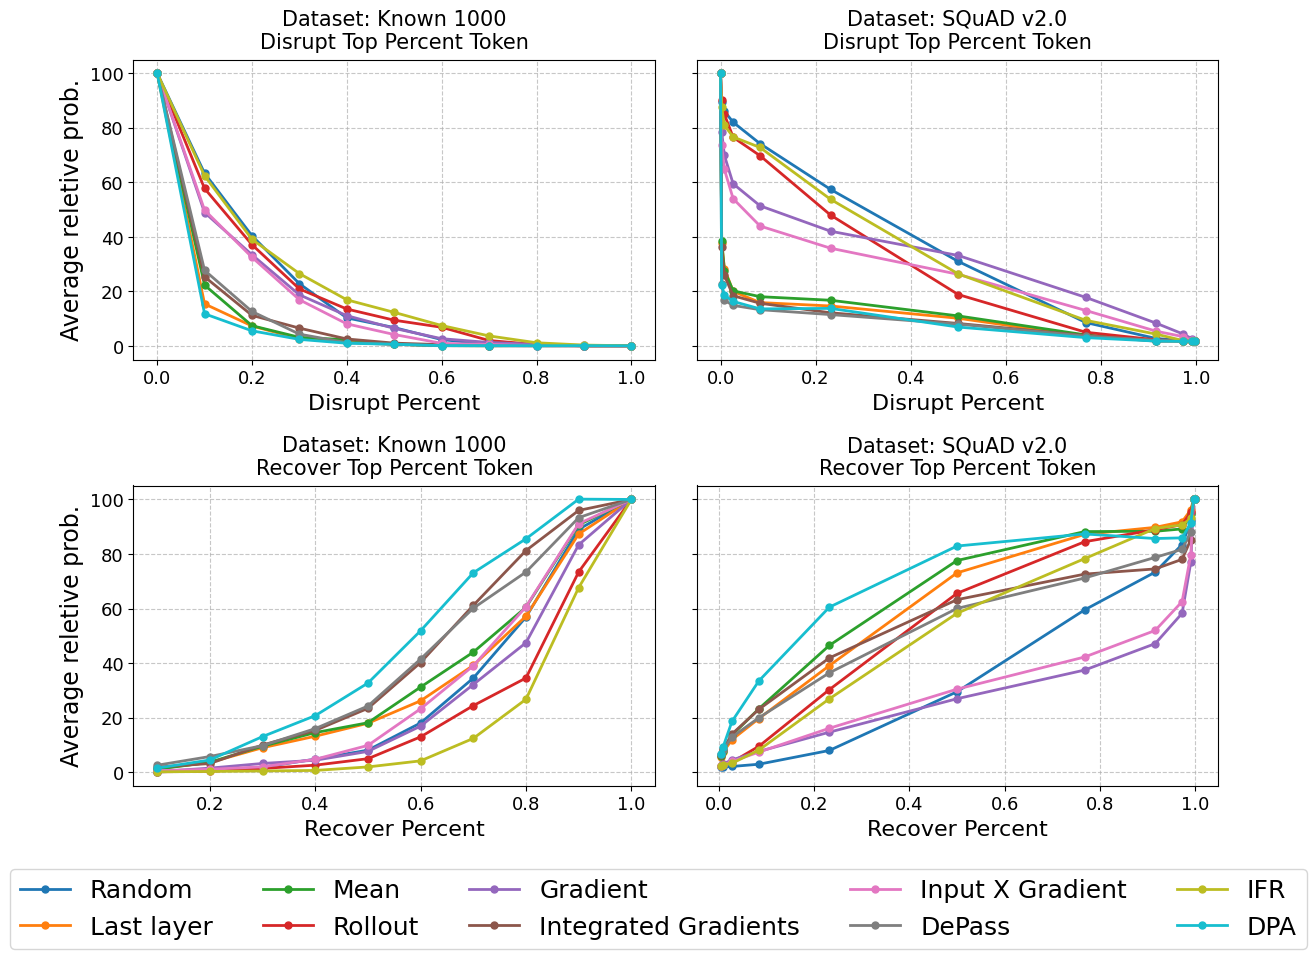

In [37]:
model = 'mistralai/Mistral-7B-Instruct-v0.3' #'Qwen/Qwen2.5-32B-Instruct', 'Qwen/Qwen3-4B-Instruct-2507', "meta-llama/Llama-2-7b-chat-hf", 'meta-llama/Llama-3.1-8B-Instruct', 'mistralai/Mistral-7B-Instruct-v0.3'
attribution = 'input' # 'input', 'component'
dataset = 'known_1000' if attribution == 'component' else 'imdb' # for AOC cells below

plot_input_results_three_datasets(
    model,
    attribution=attribution,
)

In [38]:
# AUC scores for current model
attribution = 'input'
dataset = 'squad_v2.0'
single_aoc_df = compute_aoc_table([model], attribution, dataset)
auc_scores = single_aoc_df[["method", "disturb_aoc", "recover_aoc", "total_aoc"]]
display(auc_scores)

,method,disturb_aoc,recover_aoc,total_aoc
0,attn_rollout,27.94,56.88,28.94
1,depass,7.92,53.93,46.01
2,dpa_025_025_05_05_05,8.06,70.97,62.91
3,gradient,31.19,27.56,-3.63
4,ifr,32.56,52.78,20.22
5,input_x_gradient,25.65,30.44,4.79
6,integrated_gradient,8.67,55.98,47.31
7,last_layer_attn,9.79,62.84,53.05
8,mean_attn,10.78,65.99,55.21
9,random,34.63,34.68,0.05
